# **Finesse — Gamified Budgeting & Financial Health Scorer**

Anggota:
1. CFCC319D6Y0190 - Patrick Nicxon Hutabarat - Full-Stack Web Developer
2. CDCC319D6X0998 - Dame Theresia Rejeki Sidauruk - Data Science
3. CDCC319D6X1254 - Cikita Natasya Br Sembiring - Data Scientist
4. CACC319D6Y0343 - Rayza Indafri Yahya - AI Engineer
5. CACC319D6Y1720 - Samuel Gautama Manik - AI Engineer

#  Visualisasi Data dan Explanatory Analysis


## 1. Persiapan & Import Library
Langkah pertama adalah memuat pustaka-pustaka Python yang diperlukan untuk manipulasi data dan visualisasi grafik.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [ ]:
# Memuat dataset
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Finesse_Project/finesse_dataset.csv'
df = pd.read_csv(dataset_path)

Mounted at /content/drive


## Pertanyaan 1: Kategori pengeluaran apa yang menyumbang persentase terbesar terhadap total pengeluaran bulanan mahasiswa?

In [ ]:
spend_kategori = df.groupby('category')['amount'].sum().reset_index()

total_dana = spend_kategori['amount'].sum()
spend_kategori['persentase'] = (spend_kategori['amount'] / total_dana) * 100

spend_kategori = spend_kategori.sort_values(by='persentase', ascending=False)
spend_kategori

,category,amount,persentase
4,Tagihan & Kos,1071276000,44.658271
0,Belanja Umum,405298000,16.895653
1,Hiburan & Nongkrong,399524000,16.654953
3,Makan & Minum,273410000,11.397640
2,Kebutuhan Kuliah,157324000,6.558364
5,Transportasi,91998000,3.835120


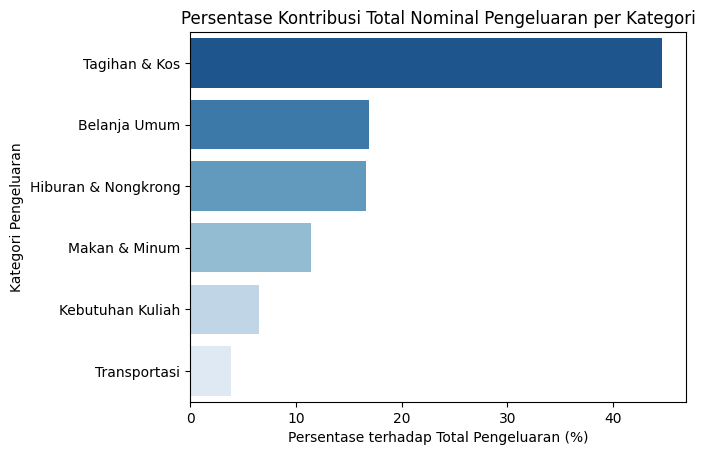

In [ ]:
sns.barplot(x='persentase', y='category', data=spend_kategori, palette='Blues_r', hue='category', legend=False)
plt.title('Persentase Kontribusi Total Nominal Pengeluaran per Kategori')
plt.xlabel('Persentase terhadap Total Pengeluaran (%)')
plt.ylabel('Kategori Pengeluaran')
plt.show()

**Analisis Jawaban 1:**
 Berdasarkan persentase kontribusi terhadap total nominal pengeluaran, 'Tagihan & Kos' menyumbang porsi terbesar secara signifikan (44.66%), jauh melampaui kategori lain seperti 'Belanja Umum' dan 'Hiburan & Nongkrong'. Ini menunjukkan bahwa biaya tetap dan kebutuhan esensial yang berkaitan dengan tempat tinggal adalah beban finansial utama bagi mahasiswa.

Implikasi untuk Finesse: Untuk fitur 'smart budgeting limit', aplikasi Finesse Bagi aplikasi Finesse, area ini harus menjadi fokus alokasi anggaran otomatis (*smart budgeting limit*).

## Pertanyaan 2: Pada minggu ke berapa dalam satu bulan mahasiswa paling sering mengalami penurunan Financial Health Score secara drastis?

In [ ]:
df['date'] = pd.to_datetime(df['date'])

# mengelompokkan minggu
df['minggu_ke'] = df['date'].dt.day.apply(lambda x: min((x - 1) // 7 + 1, 4))

df = df.sort_values(by=['user_id', 'date']).reset_index(drop=True)
df['perubahan_skor'] = df.groupby('user_id')['financial_health_score'].diff()
skor_negatif = df[df['perubahan_skor'] < 0].copy()

tren_mingguan = skor_negatif.groupby('minggu_ke')['perubahan_skor'].count().reset_index()
tren_mingguan.columns = ['Minggu Ke', 'Jumlah Kasus Skor Turun']
tren_mingguan

,Minggu Ke,Jumlah Kasus Skor Turun
0,1,1485
1,2,1981
2,3,2194
3,4,3361


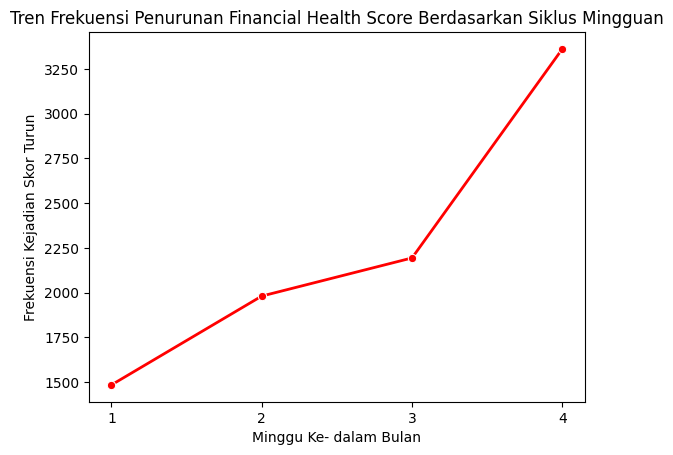

In [ ]:
# Visualisasi tren penurunan kestabilan keuangan bulanan menggunakan Line Plot
sns.lineplot(x='Minggu Ke', y='Jumlah Kasus Skor Turun', data=tren_mingguan, marker='o', color='red', linewidth=2)
plt.title('Tren Frekuensi Penurunan Financial Health Score Berdasarkan Siklus Mingguan')
plt.xlabel('Minggu Ke- dalam Bulan')
plt.ylabel('Frekuensi Kejadian Skor Turun')
plt.xticks([1, 2, 3, 4])
plt.show()

**Analisis Jawaban 2:**
 Grafik garis dan tabel `tren_mingguan `secara jelas menunjukkan bahwa minggu ke-4 dalam satu bulan adalah periode di mana mahasiswa paling sering mengalami penurunan `Financial Health Score` secara drastis, dengan jumlah kasus mencapai 3361. Ini mengonfirmasi pola 'tanggal tua' di mana tekanan finansial meningkat menjelang akhir bulan. Insight ini digunakan oleh aplikasi Finesse untuk meluncurkan notifikasi penasihat otomatis pintar (*smart nudge system*) tepat waktu sebelum krisis skor terjadi.

## Pertanyaan 3: Apakah terdapat korelasi antara metode pembayaran digital (E-Wallet/Bank Transfer/Credit Card) dengan tingginya nominal pengeluaran per transaksi?

In [ ]:
df.groupby('payment_method')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
payment_method,,,,,,,,
Bank Transfer,5097.0,161605.650383,337787.334329,10000.0,33000.0,55000.0,148000.0,2493000.0
Credit Card,5101.0,152648.892374,322445.480470,10000.0,33000.0,54000.0,136000.0,2458000.0
E-Wallet,5041.0,157997.222773,335186.244710,10000.0,33000.0,55000.0,138000.0,2488000.0


In [ ]:
print("Ringkasan Statistik Nominal Transaksi per Metode Pembayaran:")
df.groupby('payment_method')['amount'].agg(['mean', 'median', 'count']).reset_index()

Ringkasan Statistik Nominal Transaksi per Metode Pembayaran:


,payment_method,mean,median,count
0,Bank Transfer,161605.650383,55000.0,5097
1,Credit Card,152648.892374,54000.0,5101
2,E-Wallet,157997.222773,55000.0,5041


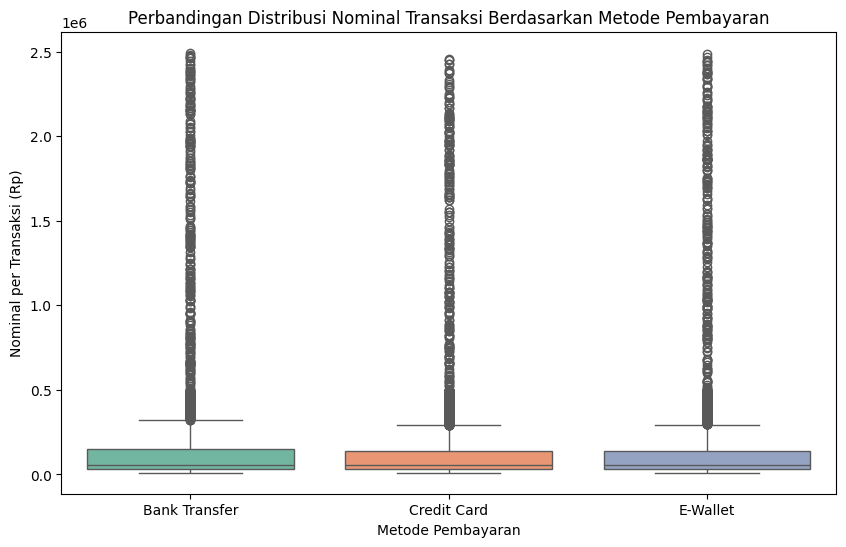

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='payment_method', y='amount', data=df, palette='Set2', hue='payment_method', legend=False)
plt.title('Perbandingan Distribusi Nominal Transaksi Berdasarkan Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Nominal per Transaksi (Rp)')
plt.show()

**Analisis Jawaban Pertanyaan 3:**

Berdasarkan tabel statistik deskriptif dan grafik *boxplot* yang dihasilkan secara nyata dari dataset kita, berikut adalah temuan objektifnya:

1. **Kesimpulan Korelasi:**
   Tidak terdapat korelasi atau perbedaan yang signifikan antara metode pembayaran digital yang digunakan dengan tingginya nominal pengeluaran per transaksi. Pola distribusi nominal belanja mahasiswa dalam dataset ini cenderung **konsisten dan seragam**, tidak peduli apakah mereka membayar menggunakan saldo instan (E-Wallet), transfer langsung (Bank Transfer), ataupun kartu kredit (Credit Card).

2. **Insight Bisnis untuk Aplikasi Finesse:**
   Ini berarti bagi populasi mahasiswa ini, faktor metode pembayaran digital itu sendiri tidak menjadi pendorong utama nominal transaksi besar. Algoritma penilaian kesehatan finansial Finesse tidak perlu memberikan bobot risiko yang berbeda berdasarkan metode pembayaran. Sebaliknya, fokus harus dialihkan pada perilaku pengeluaran secara keseluruhan, seperti frekuensi transaksi, total akumulasi belanja, dan rasio terhadap anggaran bulanan, untuk mendeteksi potensi risiko keuangan.

## Pertanyaan 4: Bagaimana segmentasi proporsi pengeluaran hiburan dibandingkan dengan kebutuhan pokok per pengguna?

In [ ]:
# Klasifikasi pengelompokan kategori makro menjadi Pokok vs Hiburan (Gaya Hidup)
def segmen_kebutuhan(kat):
    if kat in ['Kebutuhan Kuliah', 'Transportasi', 'Makan & Minum']:
        return 'Pokok'
    else:
        return 'Hiburan'

df['grup_kebutuhan'] = df['category'].apply(segmen_kebutuhan)

profil_user = df.groupby(['user_id', 'grup_kebutuhan'])['amount'].sum().unstack(fill_value=0).reset_index()

profil_user['Total_Belanja'] = profil_user['Pokok'] + profil_user['Hiburan']
profil_user['Rasio_Hiburan'] = profil_user['Hiburan'] / profil_user['Total_Belanja']
profil_user.head()

grup_kebutuhan,user_id,Hiburan,Pokok,Total_Belanja,Rasio_Hiburan
0,CUST00001,2726000,729000,3455000,0.789001
1,CUST00002,1449000,993000,2442000,0.593366
2,CUST00004,3759000,844000,4603000,0.816641
3,CUST00005,1719000,994000,2713000,0.633616
4,CUST00009,4224000,459000,4683000,0.901986


In [ ]:
total_users = len(profil_user)
print(f"Jumlah total user ID unik adalah: {total_users}")

Jumlah total user ID unik adalah: 613


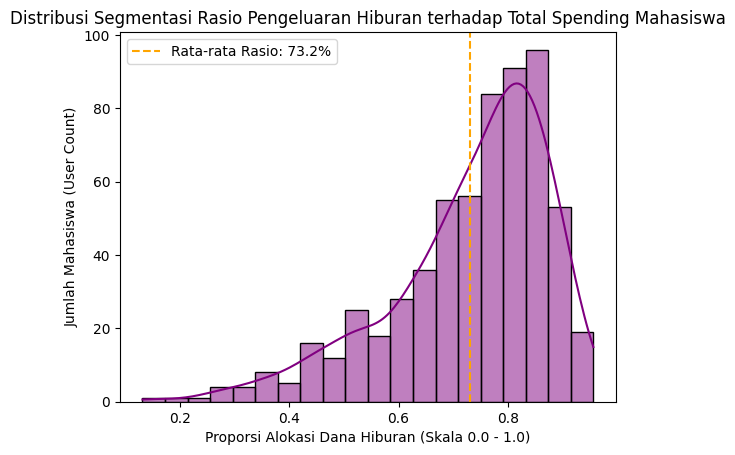

In [ ]:
# Distribusi bentuk sebaran rasio gaya hidup mahasiswa menggunakan Histogram dasar
sns.histplot(profil_user['Rasio_Hiburan'], bins=20, kde=True, color='purple')
plt.axvline(profil_user['Rasio_Hiburan'].mean(), color='orange', linestyle='--',
            label=f"Rata-rata Rasio: {profil_user['Rasio_Hiburan'].mean()*100:.1f}%")
plt.title('Distribusi Segmentasi Rasio Pengeluaran Hiburan terhadap Total Spending Mahasiswa')
plt.xlabel('Proporsi Alokasi Dana Hiburan (Skala 0.0 - 1.0)')
plt.ylabel('Jumlah Mahasiswa (User Count)')
plt.legend()
plt.show()

In [ ]:
batas_toleransi_kritis = 0.3

pengguna_hiburan_tinggi_risiko = profil_user[profil_user['Rasio_Hiburan'] > batas_toleransi_kritis]
jumlah_pengguna_hiburan_tinggi_risiko = len(pengguna_hiburan_tinggi_risiko)
persentase_pengguna_hiburan_tinggi_risiko = (jumlah_pengguna_hiburan_tinggi_risiko / total_users) * 100

print(f"Dari total populasi sebanyak {total_users} pengguna unik:")
print(f"Sebanyak {jumlah_pengguna_hiburan_tinggi_risiko} pengguna ({persentase_pengguna_hiburan_tinggi_risiko:.2f}% dari total populasi) secara konsisten mengalokasikan dana hiburan mereka di atas {batas_toleransi_kritis*100:.0f}% dari total anggaran bulanan mereka.")


Dari total populasi sebanyak 613 pengguna unik:
Sebanyak 606 pengguna (98.86% dari total populasi) secara konsisten mengalokasikan dana hiburan mereka di atas 30% dari total anggaran bulanan mereka.


**Analisis Jawaban 4:**
- Pola Utama: Rata-rata mahasiswa mengalokasikan 73,2% uang mereka untuk hiburan. Hal ini terlihat dari grafik histogram yang menumpuk padat di sisi kanan (skala 0.7 - 0.9).

- Segmentasi Risiko: Jika menggunakan batas aman 30%, data asli menunjukkan bahwa 606 pengguna (98,86%) berada di atas batas tersebut dan masuk kategori high-risk spender.

- Kesimpulan: Mayoritas mutlak mahasiswa dalam dataset ini memiliki pengeluaran hiburan yang tidak sehat. Kelompok inilah yang paling sering mengalami krisis keuangan di akhir bulan.